# 📈 K-Nearest Neighbors Regressor - Complete Learning Guide

## Overview
KNN Regressor extends the k-nearest neighbors algorithm to regression tasks. Instead of majority voting, it averages the values of k nearest neighbors. Can be weighted (closer neighbors have more influence) for better results.

## Key Topics Covered:
1. **KNN Regression Basics** - Averaging vs voting
2. **Uniform vs Weighted** - Distance-weighted averaging
3. **Choosing k** - Impact on prediction smoothness
4. **Distance Metrics** - Euclidean, Manhattan, Minkowski
5. **Feature Scaling** - Critical for distance metrics
6. **Performance Metrics** - MSE, MAE, R² scores
7. **Hyperparameter Tuning** - Optimal k and weights
8. **Advantages & Disadvantages** - When to use

---

## References:
- [KNN Regression - scikit-learn](https://scikit-learn.org/stable/modules/neighbors.html#regression)
- [K-Nearest Neighbors](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm)
- [KNN Regression Tutorial](https://www.youtube.com/watch?v=9T9L_W_Z7XU)

## 📚 Section 1: Import Libraries

In [19]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📈 Section 2: KNN Regression Basics


📈 EXAMPLE 1: Basic KNN Regression

✅ KNN Regressor (k=5, weights=uniform) Results:
  MSE:  108.1420
  RMSE: 10.3991
  MAE:  8.6740
  R²:   0.9350


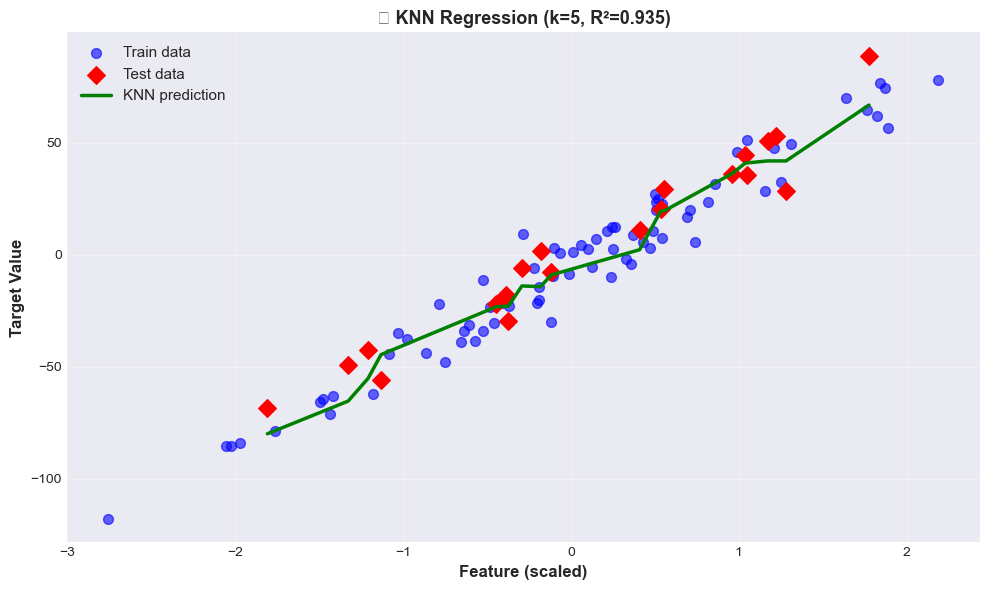

In [20]:
# Example 1: Basic KNN Regression
print("\n" + "="*70)
print("📈 EXAMPLE 1: Basic KNN Regression")
print("="*70)

# Create synthetic regression data
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=5, weights='uniform')
knn_reg.fit(X_train_scaled, y_train)
y_pred = knn_reg.predict(X_test_scaled)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n✅ KNN Regressor (k=5, weights=uniform) Results:")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R²:   {r2:.4f}")

# Visualization
X_test_sorted = X_test_scaled[np.argsort(X_test_scaled[:, 0])]
y_test_sorted = y_test[np.argsort(X_test_scaled[:, 0])]
y_pred_sorted = knn_reg.predict(X_test_sorted)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_train_scaled, y_train, c='blue', label='Train data', s=50, alpha=0.6)
ax.scatter(X_test_sorted, y_test_sorted, c='red', label='Test data', s=80, marker='D')
ax.plot(X_test_sorted, y_pred_sorted, 'g-', linewidth=2.5, label='KNN prediction')

ax.set_xlabel('Feature (scaled)', fontsize=12, fontweight='bold')
ax.set_ylabel('Target Value', fontsize=12, fontweight='bold')
ax.set_title(f'📈 KNN Regression (k=5, R²={r2:.3f})', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ⚖️ Section 3: Uniform vs Weighted


⚖️ EXAMPLE 2: Uniform vs Weighted Averaging

📊 Comparing uniform vs weighted KNN:
  k= 1: Uniform R²=0.8641, Weighted R²=0.8641
  k= 3: Uniform R²=0.9226, Weighted R²=0.8993
  k= 5: Uniform R²=0.9350, Weighted R²=0.9073
  k= 7: Uniform R²=0.9390, Weighted R²=0.9157
  k=15: Uniform R²=0.9016, Weighted R²=0.9194
  k=25: Uniform R²=0.8480, Weighted R²=0.9189


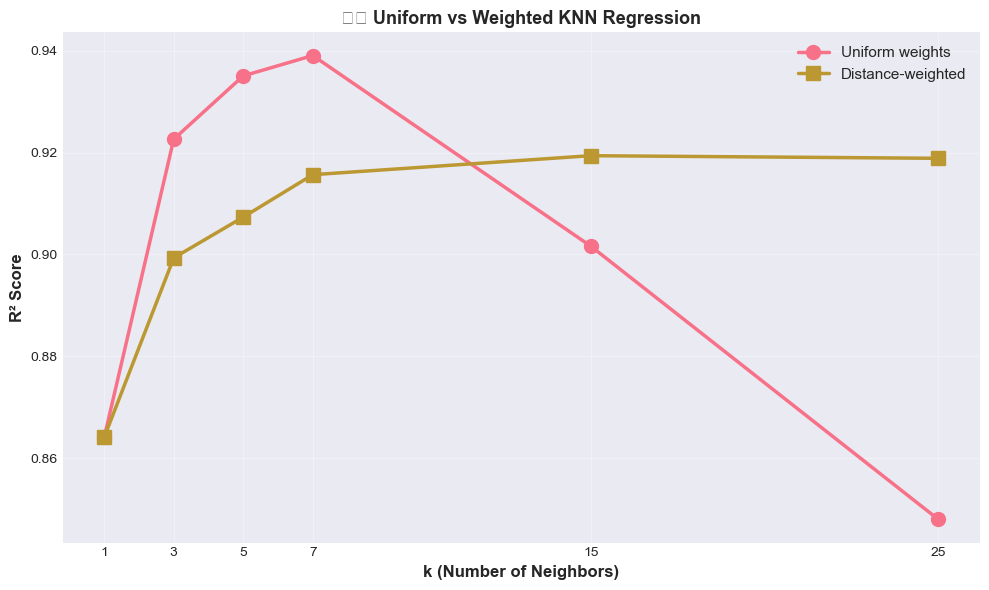


✅ Weighted KNN usually performs better!
   Closer neighbors get more influence (weight = 1/distance)


In [21]:
# Example 2: Uniform vs Weighted Averaging
print("\n" + "="*70)
print("⚖️ EXAMPLE 2: Uniform vs Weighted Averaging")
print("="*70)

k_values = [1, 3, 5, 7, 15, 25]
uniform_scores = []
weighted_scores = []

print(f"\n📊 Comparing uniform vs weighted KNN:")
for k in k_values:
    # Uniform
    knn_uniform = KNeighborsRegressor(n_neighbors=k, weights='uniform')
    knn_uniform.fit(X_train_scaled, y_train)
    r2_uniform = knn_uniform.score(X_test_scaled, y_test)
    uniform_scores.append(r2_uniform)
    
    # Weighted
    knn_weighted = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn_weighted.fit(X_train_scaled, y_train)
    r2_weighted = knn_weighted.score(X_test_scaled, y_test)
    weighted_scores.append(r2_weighted)
    
    print(f"  k={k:2d}: Uniform R²={r2_uniform:.4f}, Weighted R²={r2_weighted:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_values, uniform_scores, 'o-', linewidth=2.5, markersize=10, label='Uniform weights')
ax.plot(k_values, weighted_scores, 's-', linewidth=2.5, markersize=10, label='Distance-weighted')

ax.set_xlabel('k (Number of Neighbors)', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('⚖️ Uniform vs Weighted KNN Regression', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(k_values)

plt.tight_layout()
plt.show()

print(f"\n✅ Weighted KNN usually performs better!")
print(f"   Closer neighbors get more influence (weight = 1/distance)")

## 🔍 Section 4: Impact of k on Smoothness

# Example 3: k Impact on Prediction Smoothness
print("\n" + "="*70)
print("🔍 EXAMPLE 3: Impact of k on Prediction Smoothness")
print("="*70)

k_test = [1, 3, 7, 21]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🔍 KNN Regression: Smoothness vs k', fontsize=14, fontweight='bold')

print(f"\n📊 Visualizing k impact on predictions:")
for idx, k in enumerate(k_test):
    ax = axes[idx // 2, idx % 2]
    
    knn_k = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn_k.fit(X_train_scaled, y_train)
    r2_k = knn_k.score(X_test_scaled, y_test)
    y_pred_k = knn_k.predict(X_test_sorted)
    
    print(f"  k={k:2d}: R²={r2_k:.4f}")
    
    ax.scatter(X_train_scaled, y_train, c='blue', s=40, alpha=0.6, label='Train')
    ax.scatter(X_test_sorted, y_test_sorted, c='red', s=60, marker='D', label='Test')
    ax.plot(X_test_sorted, y_pred_k, 'g-', linewidth=2.5, label='KNN')
    
    ax.set_xlabel('Feature (scaled)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Target', fontsize=11, fontweight='bold')
    ax.set_title(f'k={k} (R²={r2_k:.3f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Observations:")
print(f"  k=1: Very wiggly (overfitting) - follows training data exactly")
print(f"  k=3: Still wiggly but smoother")
print(f"  k=7,21: Smoother predictions, better generalization")

## 📊 Section 5: Multi-dimensional Regression


📊 EXAMPLE 4: Multi-dimensional Regression

✅ KNN Regressor on 5D data (k=5):
  R²:   0.8188
  RMSE: 39.6754
  MAE:  31.3491


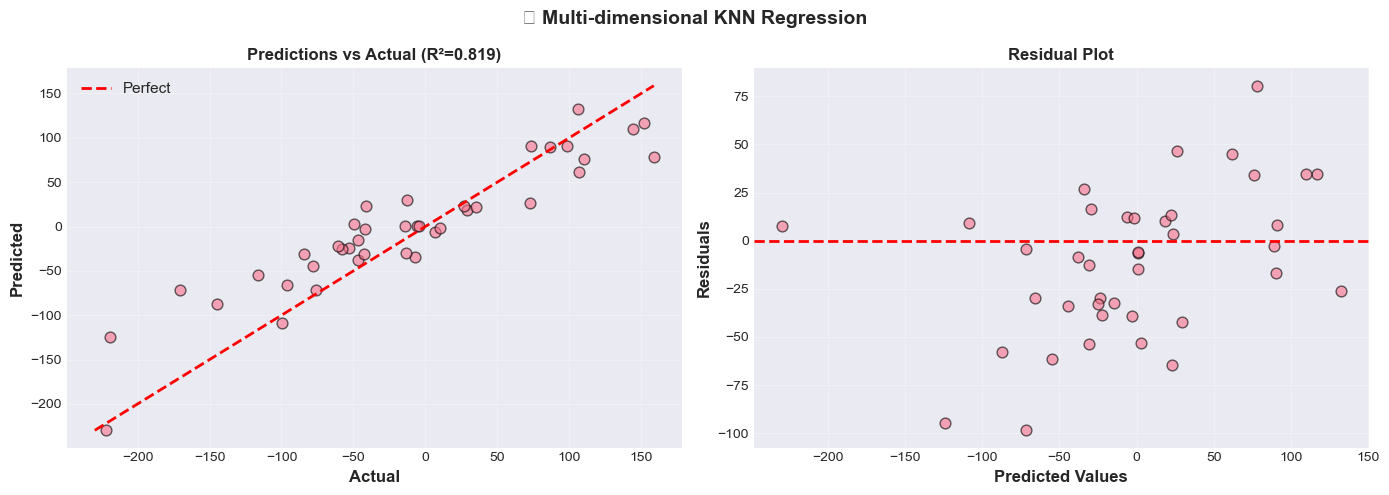

In [22]:
# Example 4: Multi-dimensional Regression
print("\n" + "="*70)
print("📊 EXAMPLE 4: Multi-dimensional Regression")
print("="*70)

# Create multi-dimensional data
X_multi, y_multi = make_regression(n_samples=200, n_features=5, noise=15, random_state=42)

# Split and scale
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42)

scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

# KNN on multi-dimensional data
knn_multi = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn_multi.fit(X_train_m_scaled, y_train_m)
y_pred_multi = knn_multi.predict(X_test_m_scaled)

r2_multi = r2_score(y_test_m, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))
mae_multi = mean_absolute_error(y_test_m, y_pred_multi)

print(f"\n✅ KNN Regressor on 5D data (k=5):")
print(f"  R²:   {r2_multi:.4f}")
print(f"  RMSE: {rmse_multi:.4f}")
print(f"  MAE:  {mae_multi:.4f}")

# Visualization - Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Multi-dimensional KNN Regression', fontsize=14, fontweight='bold')

# Predictions vs Actual
ax = axes[0]
ax.scatter(y_test_m, y_pred_multi, alpha=0.6, s=60, edgecolors='k')
min_val = min(y_test_m.min(), y_pred_multi.min())
max_val = max(y_test_m.max(), y_pred_multi.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
ax.set_xlabel('Actual', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted', fontsize=12, fontweight='bold')
ax.set_title(f'Predictions vs Actual (R²={r2_multi:.3f})', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Residuals
residuals = y_test_m - y_pred_multi
ax = axes[1]
ax.scatter(y_pred_multi, residuals, alpha=0.6, s=60, edgecolors='k')
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Values', fontsize=12, fontweight='bold')
ax.set_ylabel('Residuals', fontsize=12, fontweight='bold')
ax.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🔧 Section 6: Hyperparameter Tuning

In [23]:
# Example 5: GridSearchCV for KNN Regression
print("\n" + "="*70)
print("🔧 EXAMPLE 5: GridSearchCV for KNN Regressor")
print("="*70)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

print(f"\n🔍 Performing GridSearchCV on 5D data...")
grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_m_scaled, y_train_m)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"  Best CV Score: {grid_search.best_score_:.4f}")

best_knn_reg = grid_search.best_estimator_
y_pred_best_reg = best_knn_reg.predict(X_test_m_scaled)
r2_best_reg = r2_score(y_test_m, y_pred_best_reg)

print(f"\n✅ Best Model Test R²: {r2_best_reg:.4f}")

# Top results
results_df = pd.DataFrame(grid_search.cv_results_)
top_5 = results_df.nlargest(5, 'mean_test_score')[['param_n_neighbors', 'param_weights', 'param_metric', 'mean_test_score']]

print(f"\n✅ Top 5 Parameter Combinations:")
for idx, row in top_5.iterrows():
    print(f"  k={row['param_n_neighbors']}, weights={row['param_weights']}, metric={row['param_metric']}: {row['mean_test_score']:.4f}")


🔧 EXAMPLE 5: GridSearchCV for KNN Regressor

🔍 Performing GridSearchCV on 5D data...

✅ Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  Best CV Score: 0.7808

✅ Best Model Test R²: 0.8198

✅ Top 5 Parameter Combinations:
  k=3, weights=distance, metric=euclidean: 0.7808
  k=5, weights=distance, metric=euclidean: 0.7761
  k=3, weights=uniform, metric=euclidean: 0.7680
  k=5, weights=uniform, metric=euclidean: 0.7615
  k=3, weights=distance, metric=manhattan: 0.7594

✅ Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  Best CV Score: 0.7808

✅ Best Model Test R²: 0.8198

✅ Top 5 Parameter Combinations:
  k=3, weights=distance, metric=euclidean: 0.7808
  k=5, weights=distance, metric=euclidean: 0.7761
  k=3, weights=uniform, metric=euclidean: 0.7680
  k=5, weights=uniform, metric=euclidean: 0.7615
  k=3, weights=distance, metric=manhattan: 0.7594


## 📋 Section 7: KNN Regressor - Advantages & Disadvantages

### ✅ Advantages:
1. **Simple and intuitive** - Easy to understand and implement
2. **No training phase** - Lazy learning approach
3. **Flexible** - Works for any dimension
4. **Weighted variant** - Distance-weighted for better results
5. **Non-parametric** - No assumptions about distribution
6. **Good baseline** - Simple starting point for comparisons

### ❌ Disadvantages:
1. **Slow prediction** - O(n) per prediction
2. **Memory intensive** - Stores entire dataset
3. **Curse of dimensionality** - Fails in high dimensions
4. **Feature scaling critical** - Distance metrics scale-dependent
5. **k selection difficult** - Performance varies with k
6. **Sensitive to outliers** - Outliers affect averages

### When to Use:
- Small to medium datasets
- Quick prototyping
- Baseline model
- Non-linear relationships
- Low to medium dimensions
- When interpretability important

In [24]:
# Example 6: Summary
print("\n" + "="*70)
print("🎓 KEY TAKEAWAYS")
print("="*70)

takeaways = [
    "KNN Regressor: Averages k nearest neighbors for prediction",
    "Uniform weights: Simple average of neighbors",
    "Distance weights: Closer neighbors have more influence (1/distance)",
    "k selection: Large k → smooth predictions, small k → flexible",
    "k=1: Can overfit badly (follows training data)",
    "Always scale features! Distance metrics scale-dependent",
    "Prediction time O(n): Slower for large datasets",
    "Distance metrics: Euclidean often best, try Manhattan too",
    "Curse of dimensionality: Fails with too many features",
    "Sensitive to outliers: They pull average values",
    "GridSearchCV essential: Find optimal k and weights",
    "Good as baseline model before trying complex algorithms"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"\n{i:2d}. {takeaway}")

print(f"\n" + "="*70)


🎓 KEY TAKEAWAYS

 1. KNN Regressor: Averages k nearest neighbors for prediction

 2. Uniform weights: Simple average of neighbors

 3. Distance weights: Closer neighbors have more influence (1/distance)

 4. k selection: Large k → smooth predictions, small k → flexible

 5. k=1: Can overfit badly (follows training data)

 6. Always scale features! Distance metrics scale-dependent

 7. Prediction time O(n): Slower for large datasets

 8. Distance metrics: Euclidean often best, try Manhattan too

 9. Curse of dimensionality: Fails with too many features

10. Sensitive to outliers: They pull average values

11. GridSearchCV essential: Find optimal k and weights

12. Good as baseline model before trying complex algorithms

